<a href="https://colab.research.google.com/github/lorenzovaresio/AI_Medicine/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Progetto finale:

Fase 1: Caricamento del dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# After mounting, you can access your file at '/content/drive/MyDrive/HAM10000_data.pkl'

Mounted at /content/drive


Uso la libreria pandas per esplorare il dataset usando il DataFrame di Pandas:

In [ ]:
import pandas as pd

df = pd.read_pickle('/content/drive/MyDrive/HAM10000_data.pkl')
df.shape

(10015, 8)

Visualizziamo le prime 5 righe:


In [ ]:
df.head(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization,image
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,"[[[190, 153, 194], [192, 154, 196], [191, 153,..."
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,"[[[23, 13, 22], [24, 14, 24], [25, 14, 28], [3..."
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,"[[[185, 127, 137], [189, 133, 147], [194, 136,..."
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,"[[[24, 11, 17], [26, 13, 22], [38, 21, 32], [5..."
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,"[[[134, 90, 113], [147, 102, 125], [159, 115, ..."


La colonna 'image' contiene delle immagini, le visualizzo utilizzando la libreria matplotlib

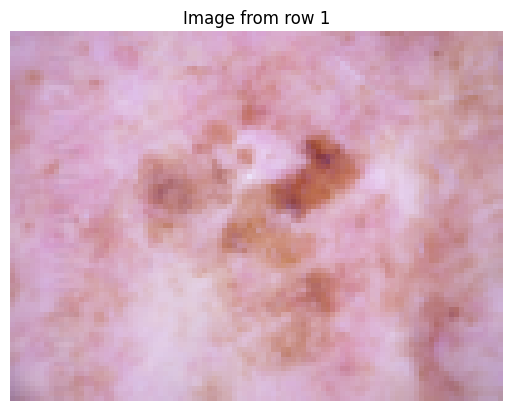

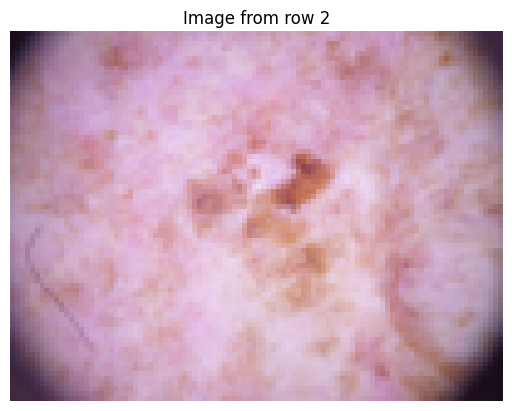

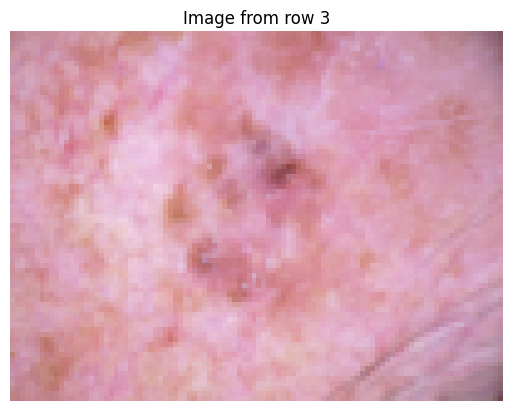

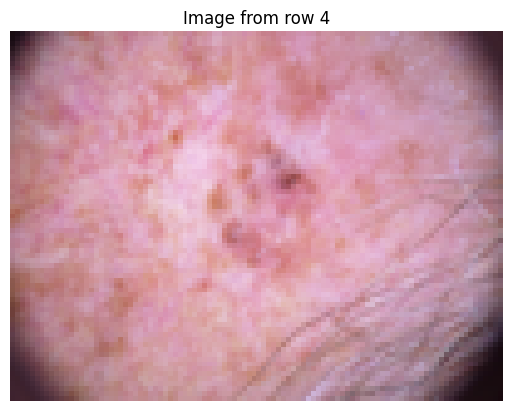

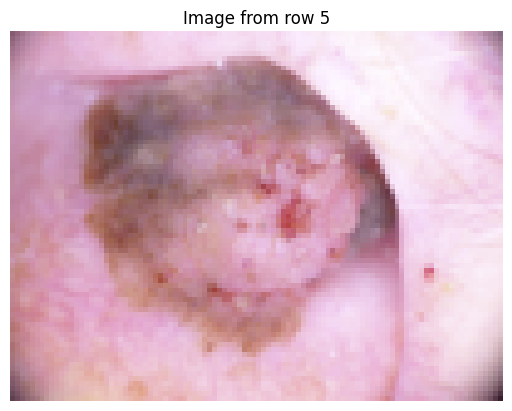

In [ ]:
import matplotlib.pyplot as plt

# Visualizza le prime 5 immagini dalla colonna 'image'
for i in range(5):
    plt.imshow(df['image'].iloc[i])
    plt.title(f"Image from row {i+1}")
    plt.axis('off')
    plt.show()

Alcune statistiche sul dataset:

In [ ]:
print("Informazioni generali sul DataFrame:")
df.info()

print("\nNumero di valori unici per 'lesion_id':")
print(df['lesion_id'].nunique())

print("\nGli 'image_id' sono tutti diversi (valori unici pari al numero di righe)?")
print(df['image_id'].nunique() == len(df))

# Informazioni sui valori unici e frequenze relative per le colonne richieste
columns_to_analyze = ['dx', 'dx_type', 'age', 'sex', 'localization']

for col in columns_to_analyze:
    print(f"\n--- Analisi della colonna: '{col}' ---")
    print(f"Numero di valori unici: {df[col].nunique()}")
    print(f"Frequenze relative dei valori:\n{df[col].value_counts(normalize=True)}")

Informazioni generali sul DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           10015 non-null  float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   image         10015 non-null  object 
dtypes: float64(1), object(7)
memory usage: 626.1+ KB

Numero di valori unici per 'lesion_id':
7470

Gli 'image_id' sono tutti diversi (valori unici pari al numero di righe)?
True

--- Analisi della colonna: 'dx' ---
Numero di valori unici: 7
Frequenze relative dei valori:
dx
nv       0.669496
mel      0.111133
bkl      0.109735
bcc      0.051323
akiec    0.032651
vasc     0.014179
df       0.011483
Name: proportion, dtyp

Prossimi step: dividere dataset in train e test, e poi capire cosa vogliamo provare a prevedere? Io forse inizirerei con:
- misurare correlazioni interessanti tra tutte le feature categoriche (escludendo le immagini dunque).
- utilizzare quelle meno correlate per fare delle combinazioni e provare a fare delle previsioni?
- data generation?